# The jet wake in MUSIC — one pair

$\Delta e = e(\text{jet}) - e(\text{no jet})$ for one 0–10% Au+Au event from `run_prod_jet.py`:
X-SCAPE's Matter + LBT shower feeds the CausalLiquefier, and its droplets are injected into a
second MUSIC run on the **same** 3D MC-Glauber initial condition as the first.

**One file, two legs.** `PairH5Writer` stores both evolutions of the event side by side: `arr`
is the jet leg (MUSIC_2, with the source) and `arr_bg` the background (MUSIC_1, without). So
`jet − bg` needs no pairing of separate runs. This is FastHydro's `jet_wake.ipynb` adapted to a
MUSIC pair. FastHydro compares two such files (ideal vs viscous); here there is **one pair**, so
every figure shows the jet leg against its own background.

**Two things differ from the FastHydro notebook:**

- **The hard process is a PYTHIA dijet, so there are two showers and two sources.** The droplet
  table does not record which shower a droplet came from. §3 assigns each droplet to a leg from
  where it sits relative to the production point, and everything after that follows *one* leg's
  track (the one that deposits the most). A single track through all droplets, as FastHydro's
  `DiffBrowser.source_track` builds, would jump back and forth between the two jets.
- **The medium is viscous MUSIC** (η/s(T) and ζ/s(T), second-order terms) with the hotQCD
  lattice EoS (MUSIC EOS 9). The notebook reads $c_s^2 = \mathrm{d}P/\mathrm{d}e$ from the same
  table MUSIC used, found through the file's `prod_build` attribute.

Only `numpy`, `h5py`, `matplotlib` and `scipy` are needed; no X-SCAPE build.

> **Scope.** One event. What it shows is the *shape and mechanism* of a wake in a realistic
> medium, not an average. The output grid is 0.3125 fm and 0.1 fm/c, so widths and freeze-out
> shifts are quantised by it.

In [1]:
%matplotlib inline
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

# The pair to read.  run_prod_jet.py writes ./out/AuAu_0_10_jet_seed<NNNN>.h5.
PATH = os.environ.get("WAKE_H5", "out/AuAu_0_10_jet_seed0001.h5")
EV = 0                               # event (pair) inside the file

# --- one fixed visual language --------------------------------------------------------------
# Legs have ASSIGNED hues (never cycled), each reinforced with a marker so they survive
# colour-vision deficiency and greyscale.  Jet vs background curves are black vs grey dashed.
LEG_C = ["#D55E00", "#0072B2", "#009E73", "#CC79A7"]
LEG_M = ["*", "D", "s", "^"]
JET_STYLE = dict(color="k", ls="-", lw=1.8, label="jet leg (arr)")
BG_STYLE = dict(color="0.55", ls="--", lw=1.8, label="background (arr_bg)")
CMAP_DIFF = "RdBu_r"        # diverging, about a neutral midpoint, for signed de
CMAP_E = "inferno"          # sequential, for e itself


def tidy(ax, xlabel=None, ylabel=None, title=None):
    '''Recessive grid and spines, so the data is the most prominent thing in the frame.'''
    ax.grid(True, alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title: ax.set_title(title, fontsize=11)
    return ax


plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
                     "legend.frameon": False})
print("ready")

ready


## 1. The data

If the file is not there, the cell prints the command that makes it (about a minute on the GPU)
rather than running it behind your back. The energy density of both legs is read into memory
once, for the frames each leg actually wrote (about 60 MB per leg).

In [2]:
if not os.path.exists(PATH):
    print(f"Missing: {PATH}\n\nMake it from this directory (js_fno env, GPU build):\n")
    print("    python run_prod_jet.py --events 1 --seed 1\n")
    print("or point the notebook at another pair:  WAKE_H5=<file.h5> jupyter lab jet_wake.ipynb")
    raise SystemExit("generate the file above, then re-run this cell")

f = h5py.File(PATH, "r")
A = f.attrs
_, _, NX, NY, NETA, NTAU = f["arr"].shape
DX, DY, DETA, DTAU = (float(A[k]) for k in ("dx", "dy", "deta", "dtau"))
x = float(A["x_min"]) + DX * np.arange(NX)
y = float(A["y_min"]) + DY * np.arange(NY)
eta = float(A["eta_min"]) + DETA * np.arange(NETA)
TAU = float(A["tau_min"]) + DTAU * np.arange(NTAU)
X, Y = np.meshgrid(x, y, indexing="ij")

NT_JET = int(f["ntau_freezeout"][EV])
NT_BG = int(f["ntau_freezeout_bg"][EV])
LIVE = min(NT_JET, NT_BG)            # frames where BOTH legs are live: the only range of a wake
E_JET = f["arr"][EV, 0, :, :, :, :NT_JET]     # (nx, ny, neta, ntau) energy density [GeV/fm^3]
E_BG = f["arr_bg"][EV, 0, :, :, :, :NT_BG]


def diff(itau):
    '''e(jet) - e(background) for one frame, (nx, ny, neta), float64.'''
    return E_JET[..., itau].astype(np.float64) - E_BG[..., itau]


DIAG = {k: float(f["diag"][k][EV]) for k in f["diag"]}
print(f"{os.path.basename(PATH)}: {A['system']}, hard = {A['prod_hard']}")
print(f"  hydro    : {A['hydro']}, {A['transport_mode']}")
print(f"  EoS      : {A['eos_kind']},  T_fo = {float(A['T_fo'])} GeV")
print(f"  jet      : {A['jet']}")
print(f"  grid     : {NX}x{NY}x{NETA}, dx = {DX} fm, deta = {DETA}, "
      f"x in [{x[0]:.1f}, {x[-1]:.1f}] fm, eta in [{eta[0]:.1f}, {eta[-1]:.1f}]")
print(f"  tau      : {TAU[0]:.2f} .. {TAU[NTAU-1]:.2f} fm/c in steps of {DTAU}; "
      f"MUSIC started at tau0 = {DIAG['tau0_music']:.3f}")
print(f"  frames   : jet {NT_JET}, background {NT_BG}, both live {LIVE} "
      f"(to tau = {TAU[LIVE-1]:.2f} fm/c)")

AuAu_0_10_jet_seed0001.h5: AuAu 200 GeV 0-10% (b in [0, 4.7] fm), hard = PythiaGun pTHat 50-70 GeV
  hydro    : MUSIC (music4gpu), MUSIC viscous: eta/s(T) and zeta/s(T) parametrization 3, second-order terms
  EoS      : hotqcd (MUSIC EOS 9),  T_fo = 0.15 GeV
  jet      : Matter + LBT, CausalLiquefier droplets into MUSIC_2
  grid     : 65x65x33, dx = 0.3125 fm, deta = 0.3125, x in [-10.0, 10.0] fm, eta in [-5.0, 5.0]
  tau      : 0.50 .. 11.00 fm/c in steps of 0.1; MUSIC started at tau0 = 0.400
  frames   : jet 106, background 95, both live 95 (to tau = 9.90 fm/c)


## 2. Controls

Nothing below means anything unless these hold. Each is a property the *pairing* must have,
not a property of the physics:

1. both legs start from the same initial condition, otherwise `jet − bg` is not the jet;
2. the legs are bit-identical until the first droplet deposits: a difference before then would
   mean something else is leaking in;
3. the droplet table accounts for the energy the writer says was deposited, and says how much
   fell outside the hydro window (droplets that fire after MUSIC has stopped are never injected).

In [3]:
o0, o1 = f["source/offsets"][EV:EV + 2]
DROPS = f["source/droplets"][o0:o1]           # (M, 8): tau, x, y, eta, E, px, py, pz
TAU_DELAY = float(A["liquefier_tau_delay"])
TAU_DEP = DROPS[:, 0] + TAU_DELAY              # a droplet deposits at tau + tau_delay
R_BLOB = float(A["liquefier_c_diff"]) * TAU_DELAY   # how far a droplet has spread by then
R_EXCL = 2.0 * R_BLOB

ok = True
print("(1) both legs share an initial condition")
same_ic = bool(np.array_equal(E_JET[..., 0], E_BG[..., 0]))
ok &= same_ic
print(f"      first frame identical: {same_ic}")

print("\n(2) bit-identical until the jet deposits")
first = next((k for k in range(LIVE) if np.any(E_JET[..., k] != E_BG[..., k])), None)
t_dep0 = float(TAU_DEP.min())
print(f"      first differing frame {first} (tau = {TAU[first]:.2f} fm/c); "
      f"first deposit at tau = {t_dep0:.2f} fm/c; writer counted "
      f"{int(DIAG['frames_identical'])} identical leading frames")
ok &= first is not None and TAU[first] >= t_dep0 - DTAU
print("      (the output grid starts at tau_min = %.2f, so a deposit before that shows up in "
      "the first frame after it)" % TAU[0])

print("\n(3) droplet accounting")
print(f"      {len(DROPS)} droplets, E_dep = {DROPS[:, 4].sum():.3f} GeV "
      f"(writer: {DIAG['E_droplets']:.3f} GeV)")
n_neg = int((DROPS[:, 4] < 0).sum())
print(f"      {n_neg} of them negative (holes left by recoils), "
      f"{DROPS[DROPS[:, 4] < 0, 4].sum():+.3f} GeV")
print(f"      outside the hydro window: early {int(DIAG['n_droplets_early'])} "
      f"({DIAG['E_droplets_early']:+.3f} GeV), late {int(DIAG['n_droplets_late'])} "
      f"({DIAG['E_droplets_late']:+.3f} GeV)")
ok &= np.isclose(DROPS[:, 4].sum(), DIAG["E_droplets"])

print(f"\ncontrols pass: {bool(ok)}")

(1) both legs share an initial condition
      first frame identical: True

(2) bit-identical until the jet deposits
      first differing frame 6 (tau = 1.10 fm/c); first deposit at tau = 1.04 fm/c; writer counted 6 identical leading frames
      (the output grid starts at tau_min = 0.50, so a deposit before that shows up in the first frame after it)

(3) droplet accounting
      25 droplets, E_dep = 24.962 GeV (writer: 24.962 GeV)
      6 of them negative (holes left by recoils), -4.179 GeV
      outside the hydro window: early 0 (+0.000 GeV), late 1 (-0.001 GeV)

controls pass: True


## 3. The event: two showers, two sources

PYTHIA produces two back-to-back partons at the same point, and each starts a shower. The droplet
table carries no shower label, so each droplet is assigned to the leg whose *transverse direction*
from the production point it lies along. That only needs the droplet's position, and it is
unambiguous for a back-to-back pair once a droplet is more than a few tenths of a fm from the
vertex; the few droplets sitting on the vertex are assigned from their momentum instead.

From here on the notebook follows the **leading-deposit leg**: the one that put the most energy
into the medium. Its track (deposit position against deposit time) is the moving source the wake
figures are drawn around. The track uses only droplets that were actually injected (deposit time
inside the jet leg's hydro window) and carry $|E| \ge$ `E_MIN_TRACK` = 0.01 GeV. Without that cut,
a single $-0.001$ GeV droplet that fires after MUSIC has stopped would stretch the track 4 fm past
the last real deposit and keep the source "active" to the end of the run.

In [4]:
i0, i1 = f["shower/initiator_offsets"][EV:EV + 2]
INI = f["shower/initiators"][i0:i1]            # shower, pid, pstat, px, py, pz, E, x, y, z, t
NLEG = len(INI)
V0 = INI[:, 7:9]                               # production point of each leg [fm]
NDIR = INI[:, 3:5] / np.linalg.norm(INI[:, 3:5], axis=1, keepdims=True)
PHI_DIR = np.arctan2(NDIR[:, 1], NDIR[:, 0])   # transverse direction of travel


def assign_legs(drops):
    '''Leg index per droplet: the leg whose transverse direction from the vertex it lies along.'''
    leg = np.empty(len(drops), int)
    for i, d in enumerate(drops):
        cos = []
        for s in range(NLEG):
            v = d[1:3] - V0[s]
            if np.hypot(*v) < 0.1:             # on the vertex: fall back to the momentum
                v = d[5:7]
            cos.append(np.dot(v, NDIR[s]) / max(np.hypot(*v), 1e-12))
        leg[i] = int(np.argmax(cos))
    return leg


LEG = assign_legs(DROPS)
E_MIN_TRACK = 0.01                             # GeV: droplets below this do not steer the track
INJ = TAU_DEP <= float(f["tau_freezeout"][EV])  # deposited while the jet leg's hydro was running
E_LEG = np.array([DROPS[LEG == s, 4].sum() for s in range(NLEG)])
L = int(np.argmax(E_LEG))                      # the leading-deposit leg

TRACK = []                                     # per leg: (M_s, 4) = tau_dep, x, y, eta, sorted
for s in range(NLEG):
    m = (LEG == s) & INJ & (np.abs(DROPS[:, 4]) >= E_MIN_TRACK)
    t = np.column_stack([TAU_DEP[m], DROPS[m, 1], DROPS[m, 2], DROPS[m, 3]])
    TRACK.append(t[np.argsort(t[:, 0])])


def source_at(s, tau):
    '''(x, y, eta) of leg s's source at proper time tau, or None before it first deposits.

    Linear in tau between deposits, parked at the last deposit after it stops.'''
    t = TRACK[s]
    if not len(t) or tau < t[0, 0]:
        return None
    return tuple(np.interp(float(tau), t[:, 0], t[:, k]) for k in (1, 2, 3))


def source_active(s, tau):
    t = TRACK[s]
    return bool(len(t) and t[0, 0] <= float(tau) <= t[-1, 0])


W_L = np.clip(DROPS[LEG == L, 4], 0, None)       # leg L deposit weights
ETA_L = float(np.average(DROPS[LEG == L, 3], weights=W_L))        # where leg L deposits in eta
IE_L = int(np.argmin(np.abs(eta - ETA_L)))

print(f"{'leg':>3} {'E [GeV]':>8} {'pT':>6} {'y':>6} {'phi dir':>8} {'droplets':>9} "
      f"{'E_dep [GeV]':>12} {'deposits over tau_dep':>24}")
for s in range(NLEG):
    px, py, pz, E = INI[s, 3:7]
    rap = 0.5 * np.log((E + pz) / (E - pz))
    t = TRACK[s]
    span = f"{t[0, 0]:.2f} .. {t[-1, 0]:.2f} fm/c" if len(t) else "-"
    print(f"{s:>3} {E:8.1f} {np.hypot(px, py):6.1f} {rap:+6.2f} {np.degrees(PHI_DIR[s]):+7.1f}° "
          f"{int((LEG == s).sum()):9d} {E_LEG[s]:12.2f} {span:>24}")
print(f"\nproduced at (x, y) = ({V0[0, 0]:+.2f}, {V0[0, 1]:+.2f}) fm, "
      f"{np.hypot(*V0[0]):.2f} fm from the centre")
print(f"following leg {L}: {E_LEG[L]:.2f} of {DROPS[:, 4].sum():.2f} GeV; it deposits around "
      f"eta_s = {ETA_L:+.2f}, so the maps below use the slice eta_s = {eta[IE_L]:+.3f}")

leg  E [GeV]     pT      y  phi dir  droplets  E_dep [GeV]    deposits over tau_dep
  0     57.9   52.7  +0.44  -146.8°        23        22.61        1.36 .. 6.70 fm/c
  1     69.6   49.9  -0.86   +31.4°         2         2.35        1.04 .. 1.18 fm/c

produced at (x, y) = (+1.34, +4.27) fm, 4.47 fm from the centre
following leg 0: 22.61 of 24.96 GeV; it deposits around eta_s = +0.31, so the maps below use the slice eta_s = +0.312


EoS table: /home/putschke/JetScape/X-SCAPE/build_gpu/EOS/hotQCD/hrg_hotqcd_eos_binary.dat
  e_fo = e(T_fo = 0.15 GeV) = 0.234 GeV/fm^3;  c_s at e = 0.3, 1, 3, 10 GeV/fm^3: 0.393, 0.411, 0.490, 0.525


<>:53: SyntaxWarning: invalid escape sequence '\e'
<>:53: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2478877/2374291470.py:53: SyntaxWarning: invalid escape sequence '\e'
  "\narrows: initial parton directions, hollow: negative droplets (all $\eta_s$)",


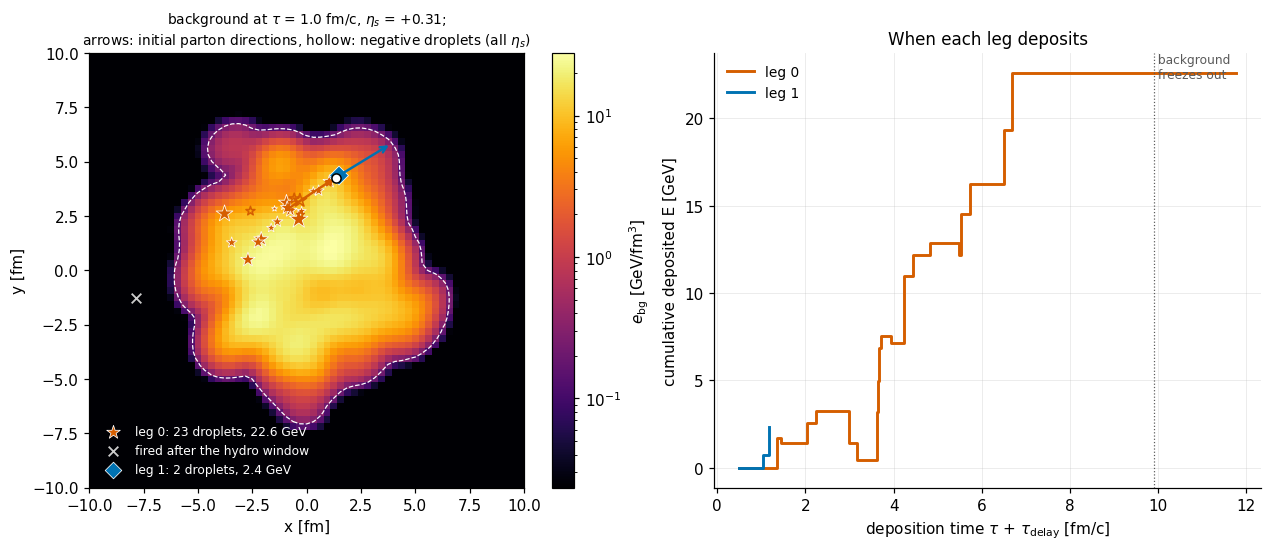

In [5]:
# Background energy density and freeze-out contour from the EoS: T_fo -> e_fo.
def find_eos_table():
    cands = [os.environ.get("MUSIC_EOS_TABLE", ""),
             os.path.join(str(A.get("prod_build", "")), "EOS", "hotQCD", "hrg_hotqcd_eos_binary.dat")]
    return next((c for c in cands if c and os.path.exists(c)), None)


EOS_PATH = find_eos_table()
if EOS_PATH:
    _t = np.fromfile(EOS_PATH, dtype="<f8").reshape(-1, 4)     # e, P, s, T (MUSIC eos_hotQCD)
    _t = _t[np.argsort(_t[:, 0])]
    EOS_E, EOS_P, EOS_T = _t[:, 0], _t[:, 1], _t[:, 3]
    EOS_CS2 = np.gradient(EOS_P, EOS_E)
    cs_of_e = lambda e: float(np.sqrt(np.clip(np.interp(np.log(max(e, EOS_E[0])),
                                                        np.log(EOS_E), EOS_CS2), 1e-6, 1)))
    E_FO = float(np.interp(float(A["T_fo"]), EOS_T, EOS_E))
    print(f"EoS table: {EOS_PATH}")
    print(f"  e_fo = e(T_fo = {float(A['T_fo'])} GeV) = {E_FO:.3f} GeV/fm^3;  c_s at e = 0.3, 1, 3, 10 "
          f"GeV/fm^3: " + ", ".join(f"{cs_of_e(v):.3f}" for v in (0.3, 1, 3, 10)))
else:
    cs_of_e, E_FO = None, 0.25
    print("hotQCD table not found (set MUSIC_EOS_TABLE): no Mach angle in section 7, "
          f"freeze-out contour drawn at e = {E_FO} GeV/fm^3")

it_show = int(np.argmin(np.abs(TAU - max(TAU_DEP.min(), TAU[0]))))
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.9), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.05, 1]})
ax = axes[0]
eb = E_BG[:, :, IE_L, it_show]
im = ax.pcolormesh(x, y, np.where(eb > 0, eb, np.nan).T, cmap=CMAP_E, shading="auto",
                   norm=plt.matplotlib.colors.LogNorm(vmin=E_FO / 10, vmax=eb.max()))
ax.contour(x, y, eb.T, levels=[E_FO], colors="w", linewidths=0.8, linestyles="--")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label=r"$e_\mathrm{bg}$ [GeV/fm$^3$]")
for s in range(NLEG):
    m = LEG == s
    d = DROPS[m]
    sz = 12 + 40 * np.abs(d[:, 4])
    inj = INJ[m]
    pos = (d[:, 4] >= 0) & inj
    neg = (d[:, 4] < 0) & inj
    ax.scatter(d[pos, 1], d[pos, 2], s=sz[pos], marker=LEG_M[s], color=LEG_C[s], ec="w", lw=0.5,
               label=f"leg {s}: {m.sum()} droplets, {E_LEG[s]:.1f} GeV", zorder=3)
    ax.scatter(d[neg, 1], d[neg, 2], s=sz[neg], marker=LEG_M[s], facecolor="none",
               ec=LEG_C[s], lw=1.0, zorder=3)
    ax.scatter(d[~inj, 1], d[~inj, 2], s=40, marker="x", color="0.8", lw=1.2, zorder=3,
               label="fired after the hydro window" if (~inj).any() else None)
    ax.annotate("", xy=V0[s] + 3.0 * NDIR[s], xytext=V0[s],
                arrowprops=dict(arrowstyle="->", color=LEG_C[s], lw=1.6))
ax.plot(*V0[0], "wo", ms=6, mec="k", zorder=4)
ax.set_aspect("equal")
ax.set(xlim=(x[0], x[-1]), ylim=(y[0], y[-1]), xlabel="x [fm]", ylabel="y [fm]")
ax.set_title(rf"background at $\tau$ = {TAU[it_show]:.1f} fm/c, $\eta_s$ = {eta[IE_L]:+.2f};"
             "\narrows: initial parton directions, hollow: negative droplets (all $\eta_s$)",
             fontsize=9)
ax.legend(loc="lower left", fontsize=8, labelcolor="w")

ax = axes[1]
for s in range(NLEG):
    m = LEG == s
    o = np.argsort(TAU_DEP[m])
    ax.step(np.r_[TAU[0], TAU_DEP[m][o]], np.r_[0, np.cumsum(DROPS[m, 4][o])], where="post",
            color=LEG_C[s], lw=1.9, label=f"leg {s}")
ax.axvline(TAU[LIVE - 1], color="0.35", lw=0.8, ls=":")
ax.text(TAU[LIVE - 1], ax.get_ylim()[1], " background\n freezes out", fontsize=8, va="top",
        color="0.35")
tidy(ax, r"deposition time $\tau$ + $\tau_\mathrm{delay}$ [fm/c]", "cumulative deposited E [GeV]",
     "When each leg deposits")
ax.legend(fontsize=9)
plt.show()

## 4. The wake in the transverse plane

Top row: the jet leg's own energy density, with the freeze-out contour. Bottom row: $\Delta e$.
Red is compression (the Mach front), blue the depletion trailing it (the diffusion wake). The
markers show where each leg's source is at that $\tau$, read from the droplet table: filled
while the leg is still depositing, hollow once it has stopped.

**One plotting decision does all the work.** Each $\Delta e$ panel uses a symmetric colour scale
that *excludes a disc of twice the deposition radius around each source and around every droplet
deposited in the last 1 fm/c* (a shower deposits from several branches at once). Scaling to the global
maximum would put the scale on the cell currently being deposited into, which runs an order of
magnitude above the wake and leaves the cone invisible.

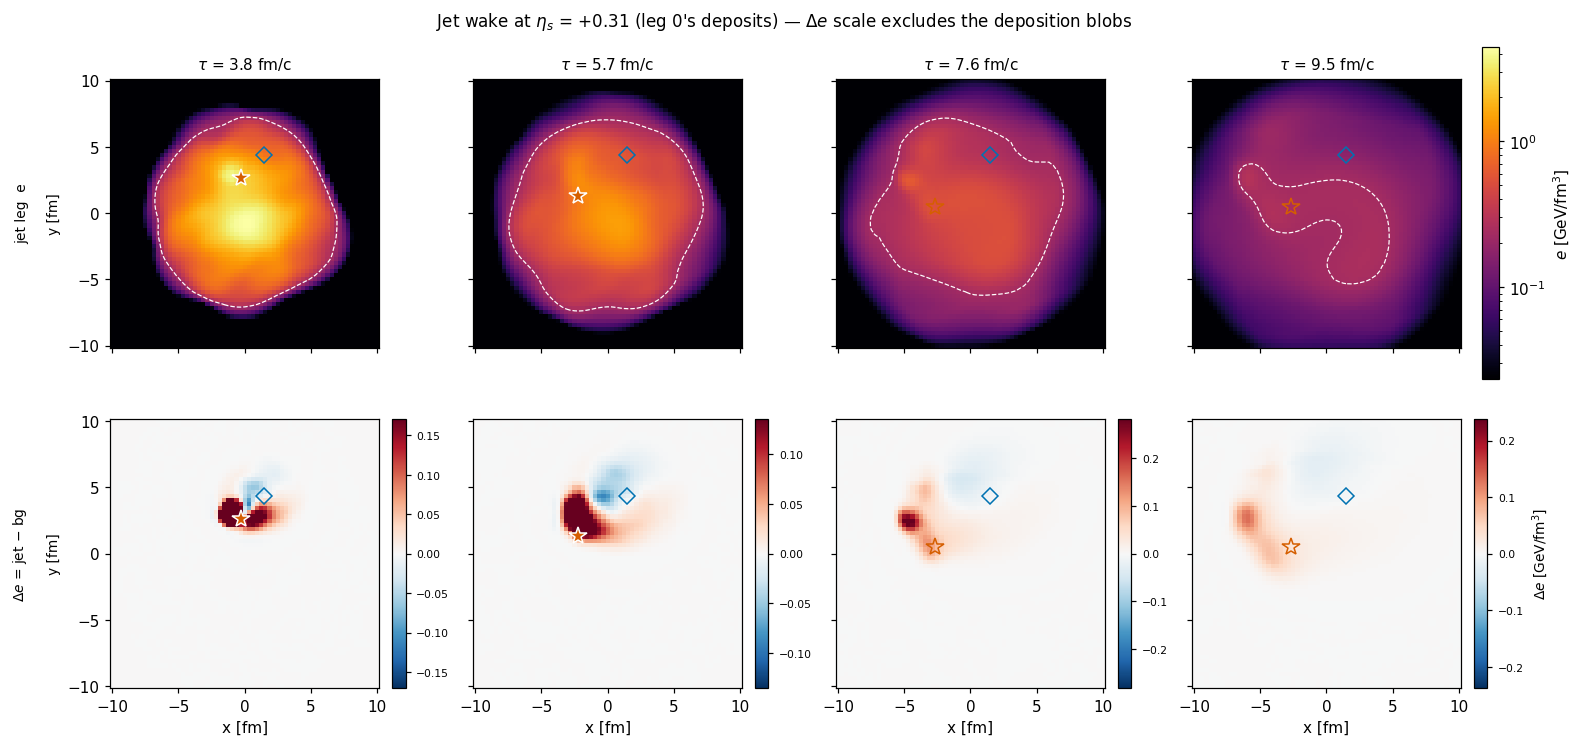

In [6]:
FRAMES = [int(round(v)) for v in np.linspace(LIVE * 0.35, LIVE * 0.95, 4)]


T_RECENT = 1.0      # fm/c: a droplet's blob is excluded this long after it deposits


def far_mask(itau):
    '''(nx, ny) True away from every leg's current source AND every recent deposit.

    A shower deposits from several branches at once, up to a few fm apart, so a disc around
    the interpolated apex alone would let a fresh side-branch deposit set the "wake" scale.'''
    far = np.ones((NX, NY), bool)
    centres = [source_at(s, TAU[itau]) for s in range(NLEG)]
    recent = INJ & (TAU_DEP <= TAU[itau]) & (TAU[itau] - TAU_DEP < T_RECENT)
    centres += [tuple(d[1:3]) for d in DROPS[recent]]
    for pos in centres:
        if pos is not None:
            far &= ((X - pos[0])**2 + (Y - pos[1])**2) > R_EXCL**2
    return far


def wake_scale(itau):
    '''max |de| OUTSIDE the deposition blobs: the wake's own scale, not the source's.'''
    de, far = diff(itau), far_mask(itau)
    return float(np.abs(de[far, :]).max()) if far.any() else float(np.abs(de).max())


def mark_sources(ax, itau):
    for s in range(NLEG):
        pos = source_at(s, TAU[itau])
        if pos is None:
            continue
        on = source_active(s, TAU[itau])
        ax.plot([pos[0]], [pos[1]], LEG_M[s], ms=12 if LEG_M[s] == "*" else 7,
                mfc=LEG_C[s] if on else "none", mec=LEG_C[s] if not on else "w", mew=1.0)


fig, axes = plt.subplots(2, len(FRAMES), figsize=(3.6 * len(FRAMES), 6.8),
                         sharex=True, sharey=True, constrained_layout=True)
e_max = max(float(E_JET[:, :, IE_L, i].max()) for i in FRAMES)
for col, itau in enumerate(FRAMES):
    ej = E_JET[:, :, IE_L, itau]
    ax = axes[0, col]
    im_e = ax.pcolormesh(x, y, np.where(ej > 0, ej, np.nan).T, cmap=CMAP_E, shading="auto",
                         norm=plt.matplotlib.colors.LogNorm(vmin=E_FO / 10, vmax=e_max))
    if ej.max() > E_FO:
        ax.contour(x, y, ej.T, levels=[E_FO], colors="w", linewidths=0.8, linestyles="--")
    mark_sources(ax, itau)
    ax.set_title(rf"$\tau$ = {TAU[itau]:.1f} fm/c", fontsize=10)

    ax = axes[1, col]
    v = max(wake_scale(itau), 1e-12)
    ax.pcolormesh(x, y, diff(itau)[:, :, IE_L].T, cmap=CMAP_DIFF, vmin=-v, vmax=v,
                  shading="auto")
    mark_sources(ax, itau)
    ax.set_xlabel("x [fm]")
    cb = fig.colorbar(ax.collections[0], ax=ax, fraction=0.05, pad=0.02)
    cb.ax.tick_params(labelsize=7)
    if col == len(FRAMES) - 1:
        cb.set_label(r"$\Delta e$ [GeV/fm$^3$]", fontsize=9)
for ax in axes.flat:
    ax.set_aspect("equal")
axes[0, 0].set_ylabel("jet leg  e\n\ny [fm]", fontsize=9)
axes[1, 0].set_ylabel(r"$\Delta e$ = jet $-$ bg" + "\n\ny [fm]", fontsize=9)
fig.colorbar(im_e, ax=axes[0, :], fraction=0.02, pad=0.01, label=r"$e$ [GeV/fm$^3$]")
fig.suptitle(rf"Jet wake at $\eta_s$ = {eta[IE_L]:+.2f} (leg {L}'s deposits) — "
             r"$\Delta e$ scale excludes the deposition blobs", fontsize=11)
plt.show()

## 5. The same wake in $\eta$ and $\varphi$

The $x$–$y$ maps show where the energy is; this shows how it is distributed in the two angles a
jet measurement bins in. Each cell's excess $\Delta e$ is weighted by its proper volume
$\tau\,\mathrm{d}x\,\mathrm{d}y\,\mathrm{d}\eta$ and summed into $(\eta, \varphi)$ bins, giving
$\mathrm{d}\Delta E / \mathrm{d}\eta\,\mathrm{d}\varphi$ in GeV.

> **These are SPATIAL angles, not the $(\eta, \varphi)$ of hadrons.** $\eta$ here is the
> spacetime rapidity $\eta_s$ of the fluid cell and $\varphi = \arctan(y/x)$ its azimuth in the
> transverse plane. The momentum-space $(\eta, \varphi)$ a detector reports needs a Cooper–Frye
> surface; this run wrote none (`--surface none`). Read these as *where the deposited energy sits
> in the fireball*.

The $\varphi$ window is centred on the azimuth of leg L's deposits (energy-weighted mean
position), so its lobe is not split by the $\pm\pi$ wrap; the ticks carry the real angles.

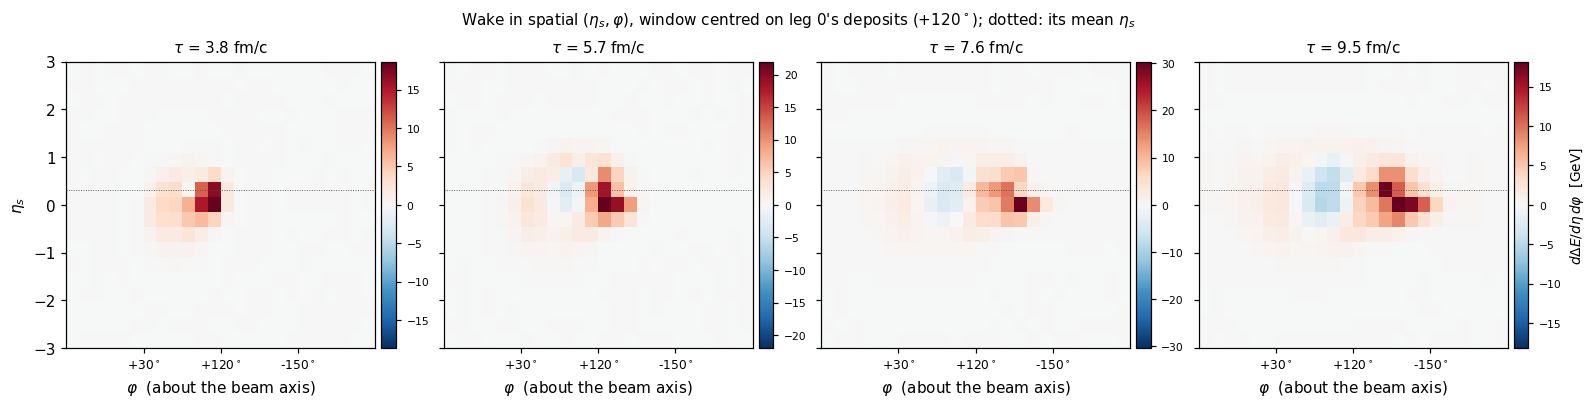

In [7]:
NPHI = 24
phi_edges = np.linspace(-np.pi, np.pi, NPHI + 1)
eta_edges = np.concatenate([eta - 0.5 * DETA, [eta[-1] + 0.5 * DETA]])
PHI_XY = np.arctan2(Y, X)                      # (nx, ny) azimuth of each transverse cell


def eta_phi(itau, *, dphi=0.0):
    '''-> (neta, NPHI) array of dE/deta dphi [GeV] about the beam axis, window centred on dphi.'''
    de = diff(itau)
    w = de * TAU[itau] * DX * DY * DETA        # GeV in each cell
    phi = np.mod(PHI_XY[:, :, None] - dphi + np.pi, 2 * np.pi) - np.pi
    H, _, _ = np.histogram2d(np.broadcast_to(eta[None, None, :], de.shape).ravel(),
                             np.broadcast_to(phi, de.shape).ravel(),
                             bins=[eta_edges, phi_edges], weights=w.ravel())
    return H / (DETA * (2 * np.pi / NPHI))


m = LEG == L
PHI0 = float(np.arctan2(np.average(DROPS[m, 2], weights=W_L), np.average(DROPS[m, 1], weights=W_L)))
_wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi
_tick = lambda off: f"{np.degrees(_wrap(PHI0 + off)):+.0f}" + r"$^\circ$"

fig, axes = plt.subplots(1, len(FRAMES), figsize=(3.6 * len(FRAMES), 3.6),
                         sharey=True, constrained_layout=True)
for ax, itau in zip(axes, FRAMES):
    H = eta_phi(itau, dphi=PHI0)
    v = max(np.abs(H).max(), 1e-12)
    ax.pcolormesh(phi_edges, eta_edges, H, cmap=CMAP_DIFF, vmin=-v, vmax=v, shading="auto")
    ax.axhline(ETA_L, color="0.3", lw=0.6, ls=":")
    ax.set_ylim(-3, 3)
    # quarter-turn ticks: the two EDGES are the same angle (the window wraps)
    ax.set_xticks([-np.pi / 2, 0, np.pi / 2])
    ax.set_xticklabels([_tick(-np.pi / 2), _tick(0.0), _tick(np.pi / 2)], fontsize=8)
    ax.set_title(rf"$\tau$ = {TAU[itau]:.1f} fm/c", fontsize=10)
    ax.set_xlabel(r"$\varphi$  (about the beam axis)")
    cb = fig.colorbar(ax.collections[0], ax=ax, fraction=0.05, pad=0.02)
    cb.ax.tick_params(labelsize=7)
axes[0].set_ylabel(r"$\eta_s$")
cb.set_label(r"$d\Delta E/d\eta\,d\varphi$  [GeV]", fontsize=9)
fig.suptitle(rf"Wake in spatial $(\eta_s, \varphi)$, window centred on leg {L}'s deposits "
             rf"({np.degrees(PHI0):+.0f}$^\circ$); dotted: its mean $\eta_s$", fontsize=10)
plt.show()

### Re-centred on the jet

$\varphi$ about the *beam axis* is not a jet-relative angle unless the jet started at the origin,
and this one did not. Here $\varphi$ is measured **about the source's own position at that
$\tau$**, with $\Delta\varphi = 0$ along leg L's initial direction of travel, and $\Delta\eta$
from the source's $\eta_s$. That is the apex of the cone: a Mach cone appears as two lobes at
$\pm\theta_M$ either side of $180°$ (behind the source), the diffusion wake as the depletion
between them.

The frame shown is one where leg L is still depositing. Once it stops, the apex is pinned to the
last deposit and what expands away from it is no longer a cone.

leg 0: initial direction -146.8 deg, deposit path -136.2 deg (first -> last deposit, 5.2 fm)
frame 51 (tau = 5.60 fm/c); leg 0 still depositing: True


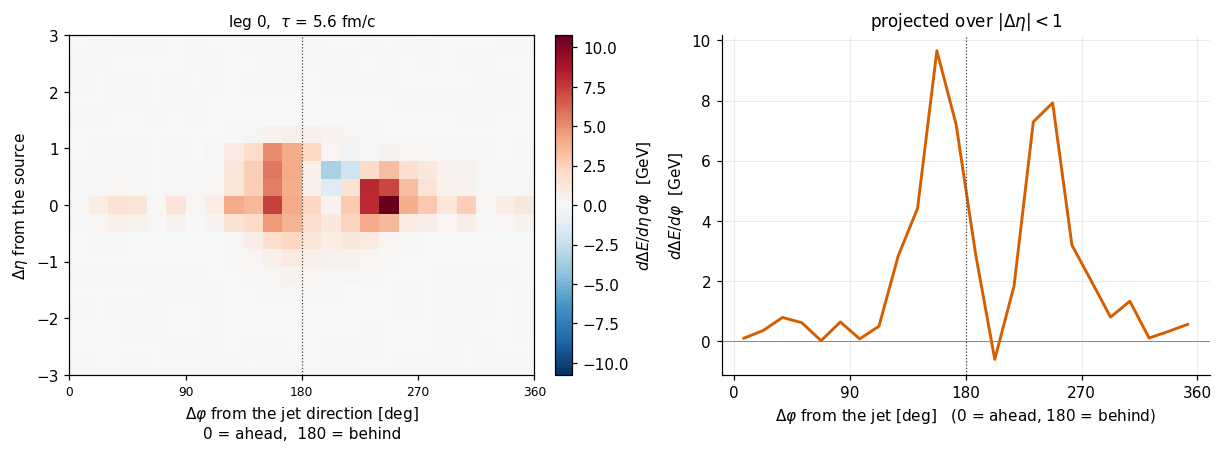

within 45 deg of the jet direction: +0.567 GeV; peak at 157 deg; total |dE/dphi| = 14.640 GeV


In [8]:
dphi_edges = np.linspace(0.0, 2 * np.pi, NPHI + 1)
dphi_cen = 0.5 * (dphi_edges[:-1] + dphi_edges[1:])

# leg L's actual path (first -> last deposit) against its initial parton direction
_t = TRACK[L]
_path = np.arctan2(_t[-1, 2] - _t[0, 2], _t[-1, 1] - _t[0, 1])
print(f"leg {L}: initial direction {np.degrees(PHI_DIR[L]):+.1f} deg, deposit path "
      f"{np.degrees(_path):+.1f} deg (first -> last deposit, {np.hypot(*(_t[-1, 1:3] - _t[0, 1:3])):.1f} fm)")


def eta_phi_jet(itau, s=L):
    '''dE/deta dphi about leg s's own position at this tau; dphi = 0 is its direction of travel.'''
    apex = source_at(s, TAU[itau])
    if apex is None:
        return None
    de = diff(itau)
    w = de * TAU[itau] * DX * DY * DETA
    phi = np.mod(np.arctan2(Y - apex[1], X - apex[0])[:, :, None] - PHI_DIR[s], 2 * np.pi)
    deta_ = np.broadcast_to(eta[None, None, :] - apex[2], de.shape)
    H, _, _ = np.histogram2d(deta_.ravel(), np.broadcast_to(phi, de.shape).ravel(),
                             bins=[eta_edges, dphi_edges], weights=w.ravel())
    return H / (DETA * (2 * np.pi / NPHI))


active = [i for i in range(LIVE) if source_active(L, TAU[i])]
IT_JET = active[int(0.8 * len(active))] if active else FRAMES[1]
print(f"frame {IT_JET} (tau = {TAU[IT_JET]:.2f} fm/c); leg {L} still depositing: "
      f"{source_active(L, TAU[IT_JET])}")
H = eta_phi_jet(IT_JET)

fig = plt.figure(figsize=(11.0, 4.0), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.05])
ax = fig.add_subplot(gs[0, 0])
v = max(np.abs(H).max(), 1e-12)
im = ax.pcolormesh(dphi_edges, eta_edges, H, cmap=CMAP_DIFF, vmin=-v, vmax=v, shading="auto")
ax.axvline(np.pi, color="0.25", lw=0.8, ls=":")
ax.set_ylim(-3, 3)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "90", "180", "270", "360"], fontsize=8)
ax.set_xlabel(r"$\Delta\varphi$ from the jet direction [deg]" "\n0 = ahead,  180 = behind")
ax.set_ylabel(r"$\Delta\eta$ from the source")
ax.set_title(rf"leg {L},  $\tau$ = {TAU[IT_JET]:.1f} fm/c", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02, label=r"$d\Delta E/d\eta\,d\varphi$  [GeV]")

ax = fig.add_subplot(gs[0, 1])
band = np.abs(0.5 * (eta_edges[:-1] + eta_edges[1:])) < 1.0
prof = H[band].sum(axis=0) * DETA
ax.plot(np.degrees(dphi_cen), prof, color=LEG_C[L], lw=1.9)
ax.axhline(0, color="0.5", lw=0.6)
ax.axvline(180.0, color="0.25", lw=0.8, ls=":")
ax.set_xticks([0, 90, 180, 270, 360])
tidy(ax, r"$\Delta\varphi$ from the jet [deg]   (0 = ahead, 180 = behind)",
     r"$d\Delta E/d\varphi$  [GeV]", r"projected over $|\Delta\eta| < 1$")
plt.show()

fwd = np.minimum(dphi_cen, 2 * np.pi - dphi_cen) < np.pi / 4
print(f"within 45 deg of the jet direction: {prof[fwd].sum() * (2 * np.pi / NPHI):+.3f} GeV; "
      f"peak at {np.degrees(dphi_cen[np.argmax(prof)]):.0f} deg; "
      f"total |dE/dphi| = {np.abs(prof).sum() * (2 * np.pi / NPHI):.3f} GeV")

## 6. How big, how much, how wide

Three reductions of the same difference, all excluding the deposition blobs (as in §4) so they
describe the *wake* and not the source:

- **amplitude**: $\max|\Delta e|$ outside the blobs;
- **total disturbance**: $\int|\Delta e|\,\mathrm{d}V$, which counts the depletion as well as the
  front;
- **front width**: the extent of the positive ridge on a cut **perpendicular to leg L's
  direction, 2 fm behind its source**, at the source's $\eta_s$. FastHydro's jet travels along
  $+x$ so a cut at fixed $x$ does; this jet travels at an angle, so the cut is sampled along
  the perpendicular (bilinear, 0.05 fm steps). Its resolution is still the 0.3125 fm cell.

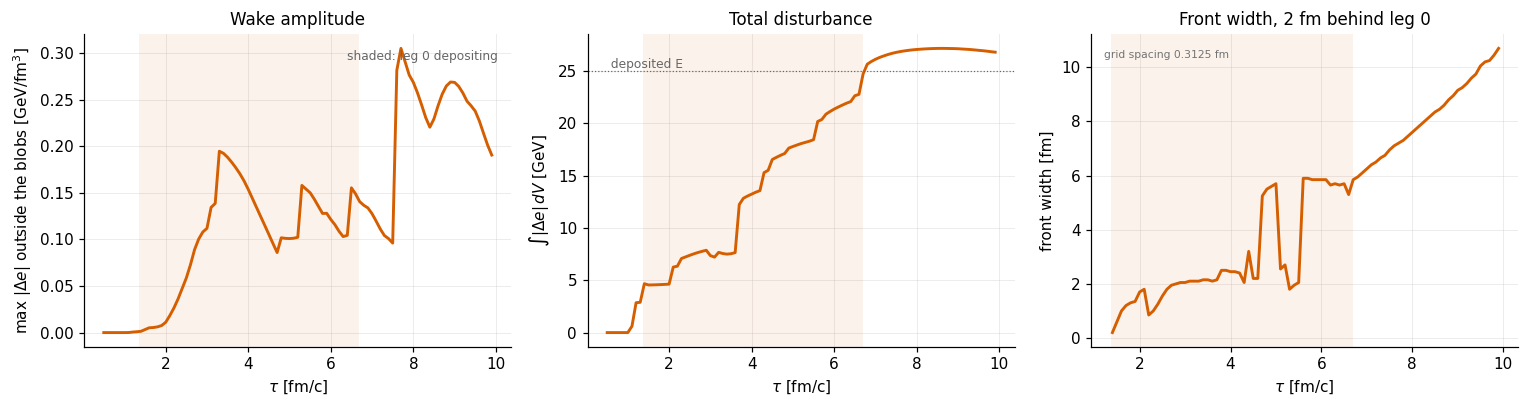

while leg 0 deposits (tau 1.4 .. 6.7): max amplitude 0.195 GeV/fm^3, front width 2.1 fm (median)
after it stops (tau > 6.7): amplitude falls to 0.191 GeV/fm^3 by tau = 9.9, total |de| dV = 26.8 GeV


In [9]:
S_CUT = np.arange(-8.0, 8.0 + 1e-9, 0.05)
N_L = NDIR[L]
PERP_L = np.array([-N_L[1], N_L[0]])


def front_width(itau):
    apex = source_at(L, TAU[itau])
    if apex is None:
        return np.nan
    ie = int(np.argmin(np.abs(eta - apex[2])))
    c = np.array(apex[:2]) - 2.0 * N_L
    pts = c[:, None] + PERP_L[:, None] * S_CUT[None, :]
    prof = map_coordinates(diff(itau)[:, :, ie], [(pts[0] - x[0]) / DX, (pts[1] - y[0]) / DY],
                           order=1, mode="constant", cval=0.0)
    if prof.max() <= 0:
        return np.nan
    m = prof > 0.2 * prof.max()
    return float(S_CUT[m].max() - S_CUT[m].min())


AMP, TOT, WID = np.full(LIVE, np.nan), np.zeros(LIVE), np.full(LIVE, np.nan)
for i in range(LIVE):
    de, far = diff(i), far_mask(i)
    if far.any():
        AMP[i] = float(np.abs(de[far, :]).max())
    TOT[i] = float(np.abs(de).sum() * TAU[i] * DX * DY * DETA)
    WID[i] = front_width(i)
t = TAU[:LIVE]
t_on, t_off = TRACK[L][0, 0], TRACK[L][-1, 0]

fig, axes = plt.subplots(1, 3, figsize=(14.0, 3.8))
for ax, v, lab, ttl in ((axes[0], AMP, r"max $|\Delta e|$ outside the blobs [GeV/fm$^3$]",
                         "Wake amplitude"),
                        (axes[1], TOT, r"$\int|\Delta e|\,dV$ [GeV]", "Total disturbance"),
                        (axes[2], WID, "front width [fm]", f"Front width, 2 fm behind leg {L}")):
    ax.axvspan(t_on, min(t_off, t[-1]), color=LEG_C[L], alpha=0.08, lw=0)
    ax.plot(t, v, color=LEG_C[L], lw=1.9)
    tidy(ax, r"$\tau$ [fm/c]", lab, ttl)
axes[1].axhline(E_LEG.sum(), color="0.4", lw=0.8, ls=":")
axes[1].text(t[0], E_LEG.sum(), " deposited E", fontsize=8, va="bottom", color="0.4")
axes[0].text(0.97, 0.95, f"shaded: leg {L} depositing", transform=axes[0].transAxes,
             fontsize=8, color="0.4", ha="right", va="top")
axes[2].text(0.03, 0.95, f"grid spacing {DY:.4g} fm", transform=axes[2].transAxes,
             fontsize=7, color="0.45", va="top")
fig.tight_layout()
plt.show()

on = (t >= t_on) & (t <= t_off)
late = t > t_off
print(f"while leg {L} deposits (tau {t_on:.1f} .. {t_off:.1f}): max amplitude "
      f"{np.nanmax(AMP[on]):.3f} GeV/fm^3, front width {np.nanmedian(WID[on]):.1f} fm (median)")
if late.any():
    print(f"after it stops (tau > {t_off:.1f}): amplitude falls to {AMP[late][-1]:.3f} "
          f"GeV/fm^3 by tau = {t[-1]:.1f}, total |de| dV = {TOT[late][-1]:.1f} GeV")

## 7. Is the front where a Mach cone should be?

The static-medium Mach half-angle is $\arcsin(c_s/v)$ with $v = 1$, with $c_s$ from the hotQCD
table at the **background** energy density at leg L's source. That is a lower bound on what the
maps show: the fireball is expanding, and the transverse flow at the front adds to $c_s$ and
opens the cone. Treat a measured angle *above* this as consistent, not as a discrepancy.

In [10]:
if cs_of_e is None:
    print("no EoS table: skipped (set MUSIC_EOS_TABLE to MUSIC's hrg_hotqcd_eos_binary.dat)")
else:
    its = sorted(set(FRAMES) | set(active[:: max(1, len(active) // 6)]))
    print(f"{'tau':>6}  {'e_bg at source':>15}  {'T':>7}  {'c_s':>6}  {'Mach half-angle':>16}"
          f"   leg {L} still depositing?")
    for itau in its:
        pos = source_at(L, TAU[itau])
        if pos is None:
            continue
        ix, iy = int(np.argmin(np.abs(x - pos[0]))), int(np.argmin(np.abs(y - pos[1])))
        ie = int(np.argmin(np.abs(eta - pos[2])))
        e0 = float(E_BG[ix, iy, ie, itau])
        cs = cs_of_e(e0)
        T0 = float(np.interp(e0, EOS_E, EOS_T))
        print(f"{TAU[itau]:6.2f}  {e0:15.3f}  {T0:7.3f}  {cs:6.3f}  "
              f"{np.degrees(np.arcsin(min(cs, 1.0))):13.1f} deg   {source_active(L, TAU[itau])}")
    print(f"\nFor comparison, a conformal EoS gives c_s = 1/sqrt(3) and 35.3 deg; the lattice EoS is")
    print("softer near the transition (min c_s^2 = %.3f), so the angle is smaller in the cold medium."
          % EOS_CS2[(EOS_T > 0.1) & (EOS_T < 0.3)].min())
    print("Once the source stops, the apex is pinned to the last deposit and the front simply")
    print("expands away from it, so the opening angle keeps growing and is no longer a Mach angle.")

   tau   e_bg at source        T     c_s   Mach half-angle   leg 0 still depositing?
  1.40            6.716    0.262   0.515           31.0 deg   True
  2.20            3.304    0.226   0.494           29.6 deg   True
  3.00            3.471    0.228   0.495           29.7 deg   True
  3.80            2.288    0.210   0.478           28.6 deg   True
  4.60            1.545    0.195   0.456           27.1 deg   True
  5.40            0.872    0.178   0.399           23.5 deg   True
  5.70            0.893    0.179   0.401           23.6 deg   True
  6.20            0.621    0.170   0.387           22.8 deg   True
  7.60            0.426    0.162   0.389           22.9 deg   False
  9.50            0.218    0.149   0.397           23.4 deg   False

For comparison, a conformal EoS gives c_s = 1/sqrt(3) and 35.3 deg; the lattice EoS is
softer near the transition (min c_s^2 = 0.150), so the angle is smaller in the cold medium.
Once the source stops, the apex is pinned to the last deposit a

## 8. Freeze-out — the jet extends the lifetime

The deposited energy reheats the medium, so the jet leg stays above $T_\text{fo}$ longer than its
own background. It is not a numerical artefact: both legs are the same MUSIC setup on the same
initial condition, differing only in the source. `tau_freezeout` comes from MUSIC's own grid;
the output frames stop at the first output time past it.

tau_freezeout: background 10.00, jet 11.10 fm/c, delta +1.10 fm/c (+11 output frames)
deposited: 24.96 GeV into the medium; 1 droplet(s) fired after the hydro window (-0.001 GeV, never injected)
MUSIC hit the grid boundary: jet False, background False


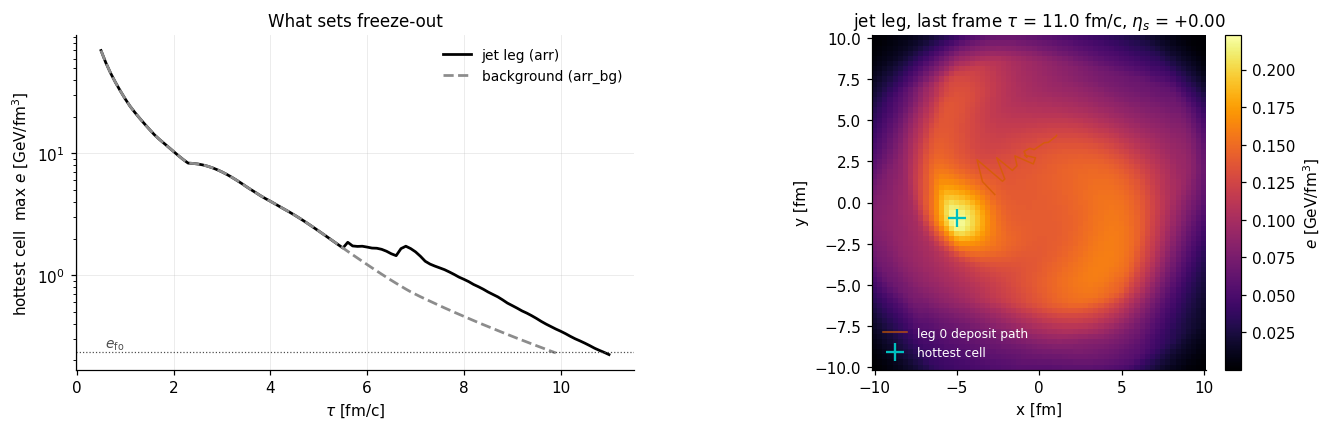

In [11]:
tb, tj = float(f["tau_freezeout_bg"][EV]), float(f["tau_freezeout"][EV])
print(f"tau_freezeout: background {tb:.2f}, jet {tj:.2f} fm/c, delta {tj - tb:+.2f} fm/c "
      f"({NT_JET - NT_BG:+d} output frames)")
print(f"deposited: {DROPS[:, 4].sum():.2f} GeV into the medium; "
      f"{int(DIAG['n_droplets_late'])} droplet(s) fired after the hydro window "
      f"({DIAG['E_droplets_late']:+.3f} GeV, never injected)")
print(f"MUSIC hit the grid boundary: jet {bool(DIAG['jet_hit_boundary'])}, "
      f"background {bool(DIAG['bg_hit_boundary'])}")

emax_j = E_JET.reshape(-1, NT_JET).max(axis=0)
emax_b = E_BG.reshape(-1, NT_BG).max(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.8), constrained_layout=True)
ax = axes[0]
ax.plot(TAU[:NT_JET], emax_j, **JET_STYLE)
ax.plot(TAU[:NT_BG], emax_b, **BG_STYLE)
ax.axhline(E_FO, color="0.3", lw=0.8, ls=":")
ax.text(TAU[0], E_FO, r" $e_\mathrm{fo}$", fontsize=9, va="bottom", color="0.3")
ax.set_yscale("log")
tidy(ax, r"$\tau$ [fm/c]", r"hottest cell  max $e$ [GeV/fm$^3$]", "What sets freeze-out")
ax.legend(fontsize=9)

# where is the last hot cell of the jet leg?
k = NT_JET - 1
ix, iy, ie = np.unravel_index(int(np.argmax(E_JET[..., k])), E_JET.shape[:3])
ax = axes[1]
ej = E_JET[:, :, ie, k]
im = ax.pcolormesh(x, y, ej.T, cmap=CMAP_E, shading="auto")
ax.contour(x, y, ej.T, levels=[E_FO], colors="w", linewidths=0.8, linestyles="--")
ax.plot(TRACK[L][:, 1], TRACK[L][:, 2], "-", color=LEG_C[L], lw=1.0, alpha=0.8,
        label=f"leg {L} deposit path")
ax.plot([x[ix]], [y[iy]], "c+", ms=12, mew=1.5, label="hottest cell")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label=r"$e$ [GeV/fm$^3$]")
tidy(ax, "x [fm]", "y [fm]",
     rf"jet leg, last frame $\tau$ = {TAU[k]:.1f} fm/c, $\eta_s$ = {eta[ie]:+.2f}")
ax.grid(False)
ax.legend(fontsize=8, loc="lower left", labelcolor="w")
plt.show()

## 9. What to take from this

The numbers quoted here are for the shipped example, `out/AuAu_0_10_jet_seed0001.h5` (seed 1);
another seed gives a different dijet and different values.

- **The difference is the wake.** Both legs start from the same initial condition and stay
  bit-identical until $\tau = 1.1$ fm/c, the first output frame after the first deposit
  (1.04 fm/c). §2 checks this rather than assuming it.
- **One dijet, one leg that matters.** The two partons are produced 4.5 fm from the centre. Leg 0
  (58 GeV) heads into the fireball and deposits 22.6 GeV between $\tau$ = 1.4 and 6.7 fm/c. Leg 1
  (70 GeV) heads out through the edge and deposits 2.4 GeV before $\tau$ = 1.2 fm/c. Following a
  single track through all the droplets would be wrong for this event.
- **A Mach-cone-like pattern behind the source.** Measured about leg 0's position while it is
  still depositing (§5, $\tau$ = 5.6 fm/c), the excess sits in two lobes near 157° and 245° from
  the jet direction, with a depletion between them. That is about ±45° about 200°. The ~20°
  offset from 180° is partly because the deposit path (−136°) is not the initial parton
  direction (−147°). The static-medium Mach angle at the source is 23–31° (§7), and a measured
  angle above it is expected in an expanding medium. With 15° bins and one event this is the
  shape of the pattern, not a measured angle.
- **Size.** Away from the deposition blobs the wake is 0.1–0.2 GeV/fm³ while the jet deposits,
  rising to 0.3 GeV/fm³ as the last large deposit (3 GeV at $\tau$ = 6.5) spreads out.
  $\int|\Delta e|\,\mathrm{d}V$ settles at about 27 GeV, the same size as the 25 GeV deposited.
  (It is not an energy balance: $|\Delta e|$ counts the depletion too, and $e$ is not
  $T^{\tau\tau}$.)
- **After the source stops, the front just expands.** The front width is about 2 fm while leg 0
  deposits. From $\tau$ = 6.7 it grows linearly by about 1.5 fm per fm/c, roughly 0.75 c per side.
  That is the sound speed ($c_s \approx 0.39$ in this cool medium) plus the radial flow, from a
  source that is no longer moving.
- **The jet extends the medium's life by 1.1 fm/c** (11 output frames). That is much more than
  FastHydro's +0.2–0.3 fm/c from 31 GeV. Here the deposits end late ($\tau$ = 6.7 fm/c) in a
  medium already close to $T_\text{fo}$, so the reheated spot at the end of leg 0's path is the
  last cell above freeze-out (§8, right panel). A deposit into a hot, early medium would move
  freeze-out much less.

**Caveats.** One event, one seed. The grid (0.3125 fm, 0.1 fm/c) quantises the widths and the
freeze-out shift. Droplets are assigned to legs geometrically, which is unambiguous for a
back-to-back pair but would need care for three or more showers. One droplet
($-0.001$ GeV) fired after the hydro window and was never injected; §2 reports it.